# Predictive Maintenance Using Linear Regression

This project uses historical electrical current data to detect unusual machine behavior.

The training data is stored in a Neon PostgreSQL database. Linear Regression models are used to estimate the expected current for Axis #1 through Axis #8.

The difference between the actual and predicted current will later be used to identify Alert and Error conditions.

In [1]:
from sklearn.linear_model import LinearRegression
import pandas as pd
## Load training data from neon db

from data_service.database_manager import Database

In [2]:
db = Database()

training_df = db.fetch_training_data()

db.close()

print("Training records retrieved:", len(training_df))

display(training_df.head())

Connected to Neon database.
Training records retrieved: 39672


,time,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Prepare the Training Data

Before training the Linear Regression models, the data is checked to make sure the time and current values are in the correct format.

The records are also kept in chronological order for time-based analysis.

In [3]:
# Check the structure and data types
training_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39672 entries, 0 to 39671
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   time    39672 non-null  datetime64[us, GMT]
 1   axis_1  39672 non-null  float64            
 2   axis_2  39672 non-null  float64            
 3   axis_3  39672 non-null  float64            
 4   axis_4  39672 non-null  float64            
 5   axis_5  39672 non-null  float64            
 6   axis_6  39672 non-null  float64            
 7   axis_7  39672 non-null  float64            
 8   axis_8  39672 non-null  float64            
dtypes: datetime64[us, GMT](1), float64(8)
memory usage: 2.7 MB


In [4]:
# Check for missing values
training_df.isnull().sum()

time      0
axis_1    0
axis_2    0
axis_3    0
axis_4    0
axis_5    0
axis_6    0
axis_7    0
axis_8    0
dtype: int64

In [5]:
# Make sure records are in chronological order
training_df = training_df.sort_values("time").reset_index(drop=True)

# Calculate elapsed time in seconds from the first reading
training_df["elapsed_seconds"] = (
    training_df["time"] - training_df["time"].iloc[0]
).dt.total_seconds()

training_df[
    ["time", "elapsed_seconds", "axis_1", "axis_2"]
].head()

,time,elapsed_seconds,axis_1,axis_2
0,2022-10-17 12:18:23.660000+00:00,0.000,0.0,0.0
1,2022-10-17 12:18:25.472000+00:00,1.812,0.0,0.0
2,2022-10-17 12:18:27.348000+00:00,3.688,0.0,0.0
3,2022-10-17 12:18:29.222000+00:00,5.562,0.0,0.0
4,2022-10-17 12:18:31.117000+00:00,7.457,0.0,0.0


### Talking Point

Linear Regression needs numerical input. The original time column is a timestamp, so it is converted into elapsed seconds starting from the first reading. This provides a numeric time variable while preserving the order of the measurements.

## 3. Train Linear Regression Models

A separate Linear Regression model is trained for each of the eight axes.

Elapsed time is used as the input, and the current reading of each axis is used as the output.

In [6]:
axis_columns = [
    "axis_1",
    "axis_2",
    "axis_3",
    "axis_4",
    "axis_5",
    "axis_6",
    "axis_7",
    "axis_8"
]

# Input for Linear Regression
X = training_df[["elapsed_seconds"]]

models = {}
regression_results = []

for axis in axis_columns:
    # Current reading for the selected axis
    y = training_df[axis]

    # Create and train the model
    model = LinearRegression()
    model.fit(X, y)

    # Store the trained model for later use
    models[axis] = model

    # Store the slope and intercept
    regression_results.append({
        "axis": axis,
        "slope": model.coef_[0],
        "intercept": model.intercept_
    })

regression_results_df = pd.DataFrame(regression_results)

regression_results_df

,axis,slope,intercept
0,axis_1,-1.176729e-07,0.730542
1,axis_2,2.194203e-06,3.523886
2,axis_3,-5.777186e-07,2.733898
3,axis_4,3.890034e-07,0.604357
4,axis_5,8.381178e-08,0.951103
5,axis_6,4.744455e-07,0.580077
6,axis_7,5.537186e-07,0.847563
7,axis_8,8.499989e-08,0.098748


### Talking Point

A separate Linear Regression model is trained for each axis because each axis can have a different current pattern.

Elapsed time is the input variable, and the current reading is the output variable. The slope shows how the expected current changes over time, while the intercept represents the predicted current when elapsed time is zero.

The trained models will later be used to calculate expected current values and residuals.

## 4. Visualize the Linear Regression Models

The actual current readings and the Linear Regression line are plotted for each axis.

The regression line represents the current values expected by the model over time.

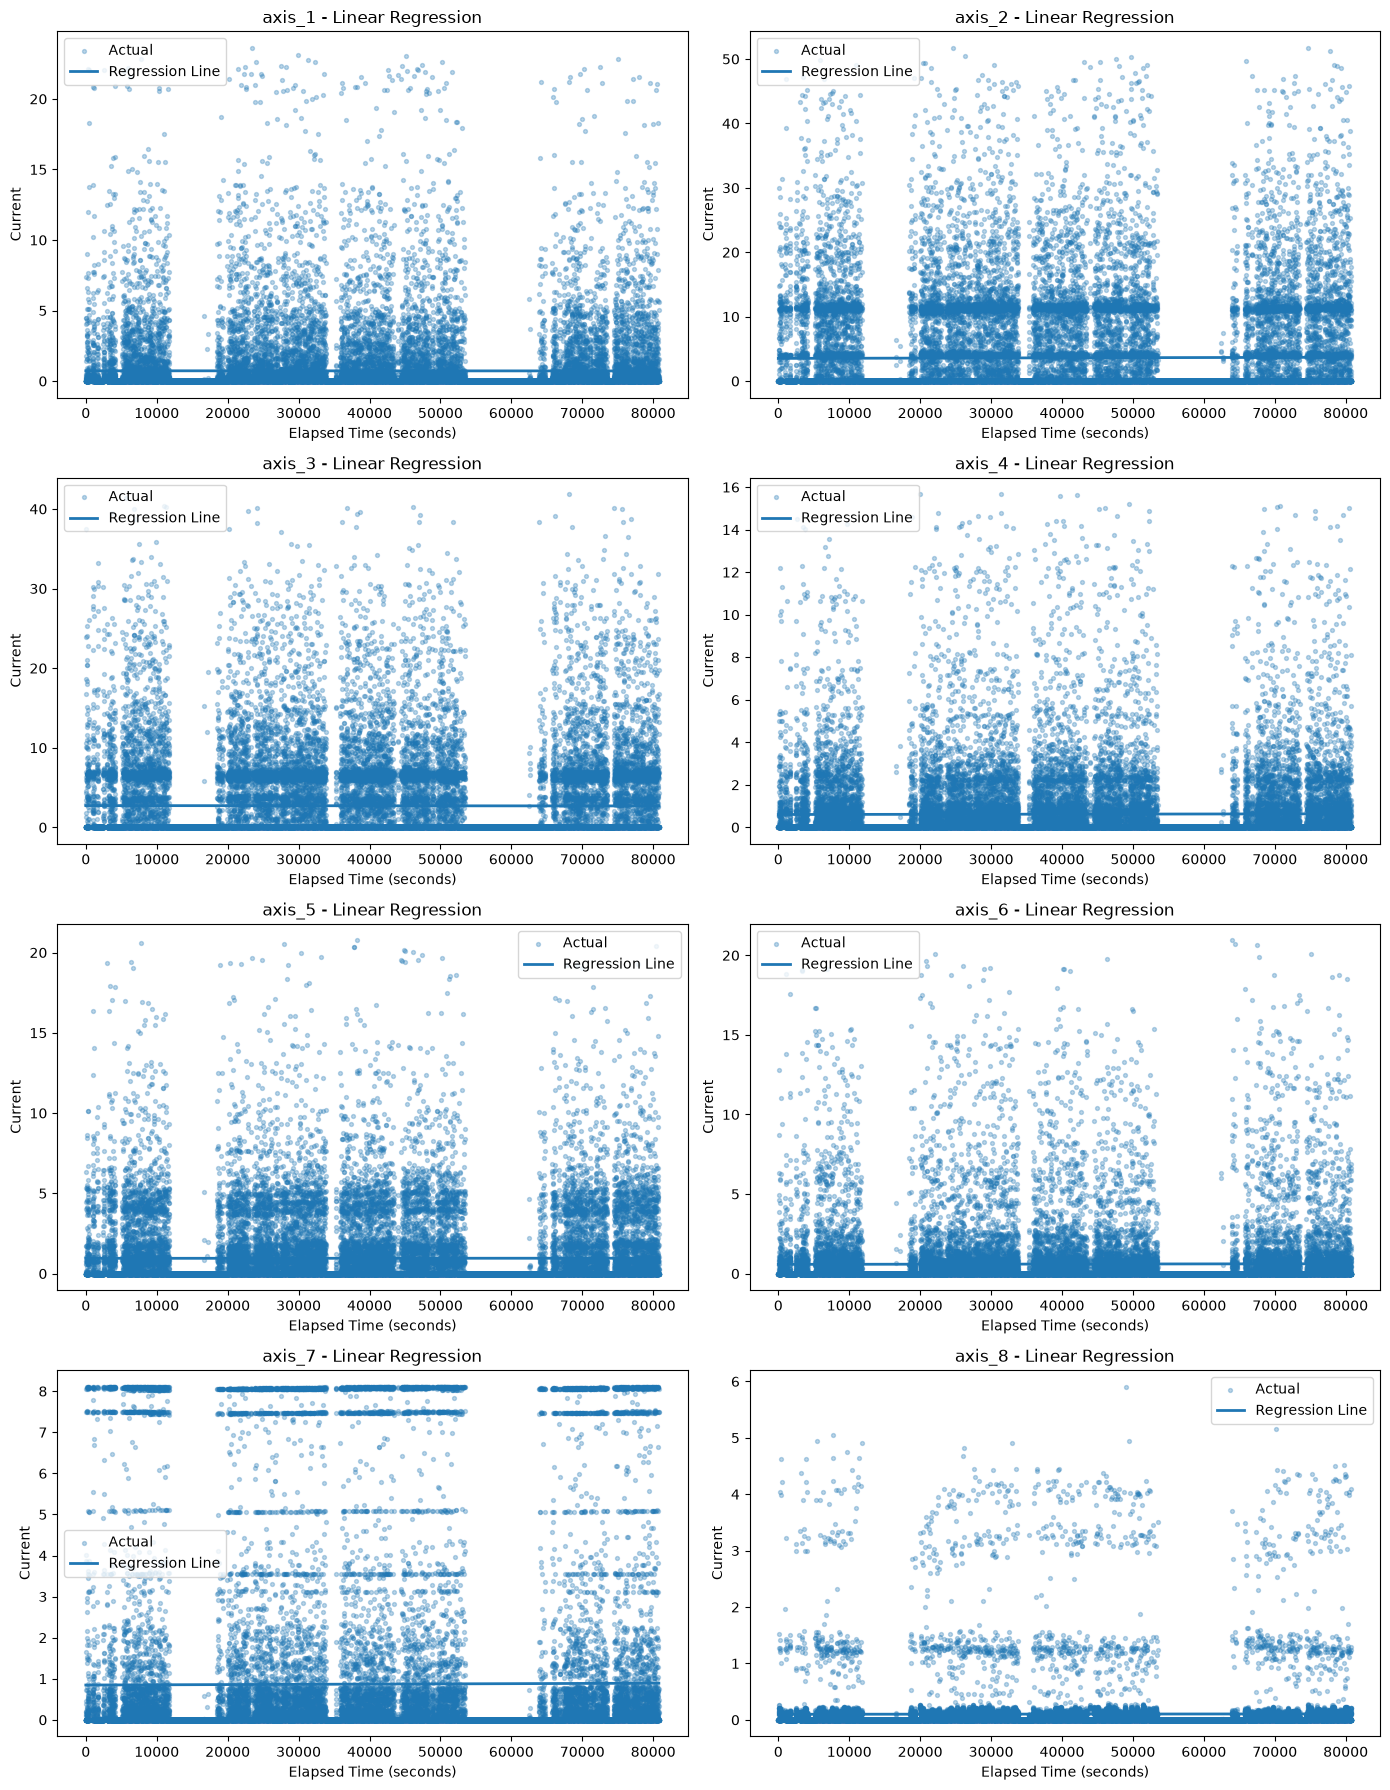

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

axes = axes.flatten()

for i, axis in enumerate(axis_columns):
    model = models[axis]

    # Predict expected current values
    predicted = model.predict(X)

    # Plot actual current readings
    axes[i].scatter(
        training_df["elapsed_seconds"],
        training_df[axis],
        alpha=0.3,
        s=8,
        label="Actual"
    )

    # Plot regression line
    axes[i].plot(
        training_df["elapsed_seconds"],
        predicted,
        linewidth=2,
        label="Regression Line"
    )

    axes[i].set_title(f"{axis} - Linear Regression")
    axes[i].set_xlabel("Elapsed Time (seconds)")
    axes[i].set_ylabel("Current")
    axes[i].legend()

plt.tight_layout()
plt.show()

### Talking Point

The scatter points show the actual current readings, while the regression line shows the expected current predicted by the model.

The distance between an actual reading and the regression line is important because it will be used to calculate the residual. Large positive residuals can indicate unusual current behavior.

## 5. Residual Analysis

A residual is the difference between the actual current reading and the current value predicted by the Linear Regression model.

Residuals are calculated for each axis to measure how far the actual current is from its expected value.

In [8]:
# Calculate predicted values and residuals for each axis

for axis in axis_columns:
    model = models[axis]

    predicted_column = f"{axis}_predicted"
    residual_column = f"{axis}_residual"

    # Expected current from Linear Regression
    training_df[predicted_column] = model.predict(X)

    # Difference between actual and expected current
    training_df[residual_column] = (
        training_df[axis] - training_df[predicted_column]
    )

In [9]:
training_df[
    [
        "elapsed_seconds",
        "axis_1",
        "axis_1_predicted",
        "axis_1_residual"
    ]
].head(10)

,elapsed_seconds,axis_1,axis_1_predicted,axis_1_residual
0,0.000,0.0,0.730542,-0.730542
1,1.812,0.0,0.730542,-0.730542
2,3.688,0.0,0.730542,-0.730542
3,5.562,0.0,0.730541,-0.730541
4,7.457,0.0,0.730541,-0.730541
5,9.304,0.0,0.730541,-0.730541
6,11.234,0.0,0.730541,-0.730541
7,13.122,0.0,0.730541,-0.730541
8,15.048,0.0,0.730540,-0.730540
9,16.869,0.0,0.730540,-0.730540


### Talking Point

A residual is calculated as the actual current minus the predicted current.

A positive residual means the actual current is above the regression line, while a negative residual means it is below the regression line.

Residuals are important in this project because they allow abnormal current increases to be measured relative to the expected current instead of using only the raw current value.

## 6. Residual Distribution

The residual distribution is examined for each axis to understand the normal amount of variation between the actual and predicted current.

This analysis will help determine suitable Alert and Error thresholds.

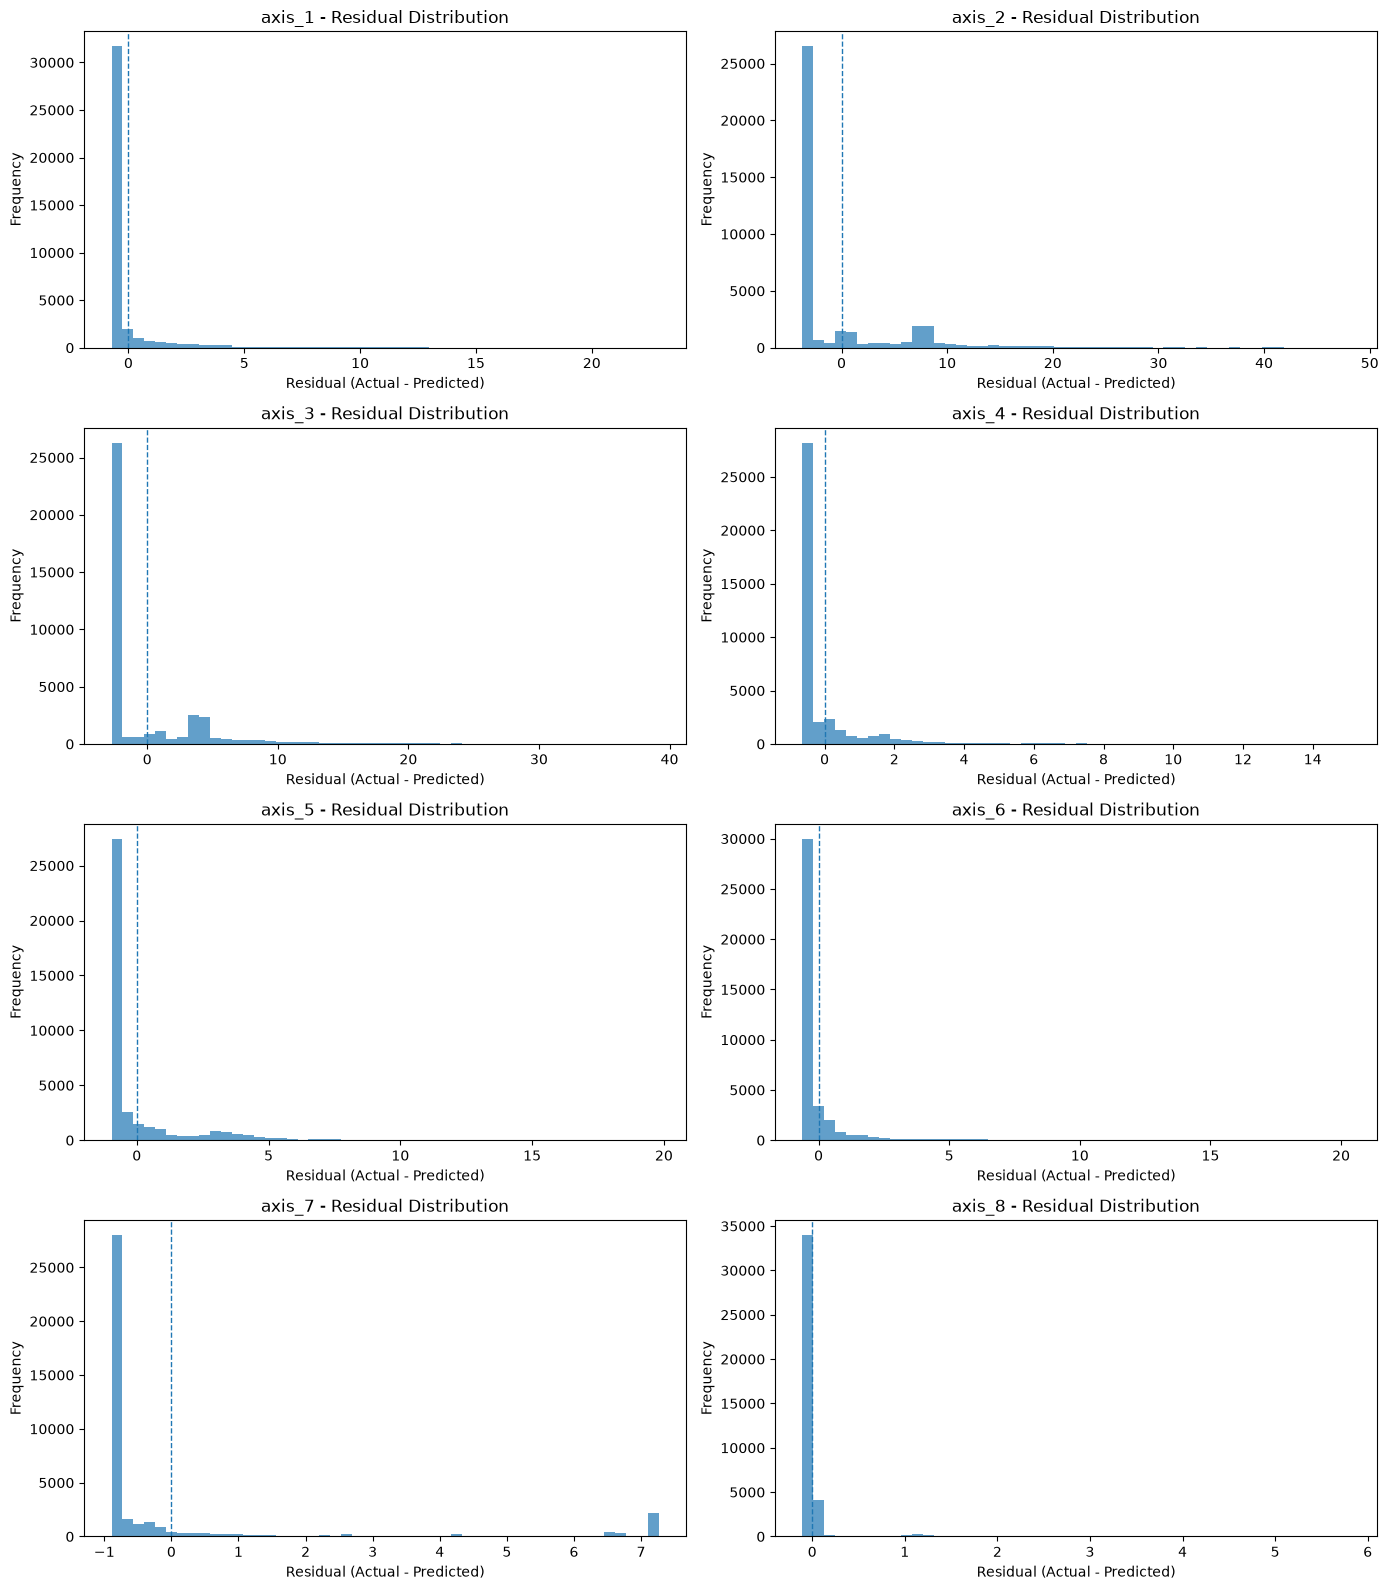

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

axes = axes.flatten()

for i, axis in enumerate(axis_columns):
    residual_column = f"{axis}_residual"

    axes[i].hist(
        training_df[residual_column],
        bins=50,
        alpha=0.7
    )

    axes[i].axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    axes[i].set_title(f"{axis} - Residual Distribution")
    axes[i].set_xlabel("Residual (Actual - Predicted)")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Talking Point

The residual distributions show how far the actual current readings normally differ from the Linear Regression predictions.

Residuals near zero are close to the expected current. Large positive residuals represent readings that are much higher than the expected current.

I analyze these distributions before selecting the Alert and Error thresholds so that the thresholds are based on the training data rather than arbitrary values.

In [11]:
residual_summary = []

for axis in axis_columns:
    residual_column = f"{axis}_residual"
    residuals = training_df[residual_column]

    residual_summary.append({
        "axis": axis,
        "mean": residuals.mean(),
        "std": residuals.std(),
        "95th_percentile": residuals.quantile(0.95),
        "99th_percentile": residuals.quantile(0.99),
        "max": residuals.max()
    })

residual_summary_df = pd.DataFrame(residual_summary)

residual_summary_df

,axis,mean,std,95th_percentile,99th_percentile,max
0,axis_1,-5.731339e-17,2.162118,3.622423,10.637570,22.881511
1,axis_2,2.980296e-16,6.879775,13.548942,27.827261,48.082660
2,axis_3,3.668057e-16,5.111883,9.756149,22.004903,39.160990
3,axis_4,6.304473e-17,1.574871,2.506291,7.724843,15.054179
4,axis_5,-8.023874e-17,2.100185,4.106583,8.931155,19.796448
5,axis_6,-1.203581e-16,1.815465,2.498980,9.737241,20.320990
6,axis_7,-1.719402e-16,2.166773,7.175265,7.227199,7.260771
7,axis_8,0.000000e+00,0.423071,0.096614,2.866628,5.802731


## 7. Discover Alert and Error Thresholds

The residual distribution is used to determine a separate threshold for each axis.

- **MinC** is the 95th percentile of the training residuals and represents the Alert threshold.
- **MaxC** is the 99th percentile of the training residuals and represents the Error threshold.

Using separate thresholds is important because each axis has a different current range and residual distribution.

In [12]:
thresholds = []

for axis in axis_columns:
    residual_column = f"{axis}_residual"
    residuals = training_df[residual_column]

    min_c = residuals.quantile(0.95)
    max_c = residuals.quantile(0.99)

    thresholds.append({
        "axis": axis,
        "MinC": min_c,
        "MaxC": max_c
    })

thresholds_df = pd.DataFrame(thresholds)

thresholds_df

,axis,MinC,MaxC
0,axis_1,3.622423,10.637570
1,axis_2,13.548942,27.827261
2,axis_3,9.756149,22.004903
3,axis_4,2.506291,7.724843
4,axis_5,4.106583,8.931155
5,axis_6,2.498980,9.737241
6,axis_7,7.175265,7.227199
7,axis_8,0.096614,2.866628


### Talking Point

I did not choose the Alert and Error thresholds randomly. I calculated them from the residual distribution of the training data.

MinC uses the 95th percentile, so unusually high positive deviations can enter the Alert region. MaxC uses the 99th percentile for more extreme deviations that can enter the Error region.

A separate MinC and MaxC is calculated for every axis because the axes have different current ranges and residual behavior.

## 8. Determine the Time Threshold

An unusual current reading should not immediately create an Alert or Error because a single reading may only be a short spike.

The timestamp intervals are analyzed to determine how frequently sensor readings occur. This information is used to select the continuous duration threshold T.

In [13]:
# Calculate the time difference between consecutive readings
time_differences = training_df["time"].diff().dt.total_seconds()

print("Median sampling interval:", time_differences.median(), "seconds")
print("Mean sampling interval:", time_differences.mean(), "seconds")
print("Minimum sampling interval:", time_differences.min(), "seconds")
print("Maximum sampling interval:", time_differences.max(), "seconds")

Median sampling interval: 1.891 seconds
Mean sampling interval: 2.036625444279196 seconds
Minimum sampling interval: 1.714 seconds
Maximum sampling interval: 402.538 seconds


### Talking Point

A single high residual may only represent a temporary spike, so the system also considers how long the abnormal condition continues.

I first analyze the sampling interval of the historical data before choosing T. This allows the duration threshold to be related to the actual timing of the sensor readings instead of selecting an arbitrary value.

### Selected Duration Threshold

The median sampling interval is approximately 1.89 seconds, meaning that sensor readings normally occur about every 2 seconds.

For this project, **T = 6 seconds** is used as the minimum continuous duration for an Alert or Error condition.

This represents approximately three normal sampling intervals and helps prevent a single short current spike from immediately generating an event.

The maximum sampling interval is much larger than the typical interval, so the median is used as the more representative value.

In [14]:
# Minimum continuous duration required for an Alert or Error
T = 6.0

print(f"Selected duration threshold T: {T} seconds")

Selected duration threshold T: 6.0 seconds


### Talking Point

The sensor readings normally occur approximately every 2 seconds. I selected T as 6 seconds, which represents about three normal sampling intervals.

This means a high residual must continue for several readings before an event is generated. This helps reduce false alerts caused by individual short spikes.

MinC and MaxC determine how large the deviation is, while T determines how long the deviation must continue.

## 9. Generate Synthetic Test Data

Synthetic sensor data is created for testing the predictive maintenance system without changing the original training data.

The mean and standard deviation of each axis in the historical training data are used to generate test readings with similar statistical characteristics.

In [15]:
import numpy as np

num_test_readings = 100
rng = np.random.default_rng(42)

synthetic_df = pd.DataFrame()

synthetic_df["time"] = pd.date_range(
    start=training_df["time"].max() + pd.Timedelta(seconds=2),
    periods=num_test_readings,
    freq="2s"
)

for axis in axis_columns:
    mean = training_df[axis].mean()
    std = training_df[axis].std()

    synthetic_df[axis] = rng.normal(
        loc=mean,
        scale=std,
        size=num_test_readings
    )

synthetic_df.head()

,time,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,2022-10-18 10:45:00.628000+00:00,1.384578,1.011630,4.435984,3.340620,0.577304,3.075516,1.986942,0.573083
1,2022-10-18 10:45:02.628000+00:00,-1.522827,12.552015,9.905244,-1.795451,1.367787,2.224634,-0.381272,-0.001465
2,2022-10-18 10:45:04.628000+00:00,2.348308,1.162291,3.173397,1.980662,2.677783,-0.706788,3.631631,-0.333897
3,2022-10-18 10:45:06.628000+00:00,2.759357,8.687453,6.002088,0.102829,0.127591,-2.128365,-0.489718,0.078118
4,2022-10-18 10:45:08.628000+00:00,-3.492629,-2.809880,-7.769940,0.523642,2.049069,-4.782669,-0.509279,0.546094


## 10. Add Test Anomalies

Sustained abnormal readings are added to the synthetic data to test whether the system can correctly detect Alert and Error conditions.

In [16]:
# Calculate elapsed time and predicted values for Axis 1
synthetic_df["elapsed_seconds"] = (
    synthetic_df["time"] - training_df["time"].iloc[0]
).dt.total_seconds()

axis_1_predicted = models["axis_1"].predict(
    synthetic_df[["elapsed_seconds"]]
)

min_c = thresholds_df.loc[
    thresholds_df["axis"] == "axis_1", "MinC"
].iloc[0]

max_c = thresholds_df.loc[
    thresholds_df["axis"] == "axis_1", "MaxC"
].iloc[0]

# Alert: residual is between MinC and MaxC
synthetic_df.loc[20:24, "axis_1"] = (
    axis_1_predicted[20:25] + (min_c + max_c) / 2
)

# Error: residual is above MaxC
synthetic_df.loc[60:64, "axis_1"] = (
    axis_1_predicted[60:65] + max_c * 1.1
)

### Talking Point

Known sustained anomalies are added to the synthetic test data so that the Alert and Error detection logic can be verified.

The detection system itself will not be told where these anomalies were added.

## 11. Standardize the Test Data

The synthetic test data is standardized using the mean and standard deviation of the training data so that it is processed relative to the historical sensor data.


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling values from training data
scaler.fit(training_df[axis_columns])

# Standardize synthetic test data
synthetic_scaled = scaler.transform(synthetic_df[axis_columns])

synthetic_scaled_df = pd.DataFrame(
    synthetic_scaled,
    columns=axis_columns
)

synthetic_scaled_df.head()



,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,0.304721,-0.378167,0.337579,1.727372,-0.179614,1.363879,0.515417,1.112980
1,-1.039997,1.299245,1.407500,-1.533881,0.196779,0.895196,-0.577546,-0.245064
2,0.750461,-0.356268,0.090586,0.863839,0.820539,-0.719489,1.274463,-1.030827
3,0.940577,0.737525,0.643947,-0.328529,-0.393746,-1.502522,-0.627595,-0.056955
4,-1.951060,-0.933629,-2.050198,-0.061325,0.521174,-2.964566,-0.636623,1.049187


### Talking Point

The scaler is fitted on the historical training data and then applied to the synthetic test data. This ensures that the test data is standardized relative to the training data.

## 12. Calculate Residuals for Test Data

The trained Linear Regression models are used to predict the expected current for the synthetic test data.

Residuals are then calculated as the difference between the actual synthetic current and the predicted current.

In [18]:
synthetic_X = synthetic_df[["elapsed_seconds"]]

for axis in axis_columns:
    synthetic_df[f"{axis}_predicted"] = models[axis].predict(synthetic_X)

    synthetic_df[f"{axis}_residual"] = (
        synthetic_df[axis] - synthetic_df[f"{axis}_predicted"]
    )
    
synthetic_df[
    ["time", "axis_1", "axis_1_predicted", "axis_1_residual"]
].head()

,time,axis_1,axis_1_predicted,axis_1_residual
0,2022-10-18 10:45:00.628000+00:00,1.384578,0.721034,0.663543
1,2022-10-18 10:45:02.628000+00:00,-1.522827,0.721034,-2.243862
2,2022-10-18 10:45:04.628000+00:00,2.348308,0.721034,1.627274
3,2022-10-18 10:45:06.628000+00:00,2.759357,0.721034,2.038323
4,2022-10-18 10:45:08.628000+00:00,-3.492629,0.721034,-4.213662


### Talking Point

The trained models predict the expected current for each synthetic reading. The residual shows how far the actual test reading is above or below that expected value.

## 13. Detect Alert and Error Conditions

Each residual is compared with the MinC and MaxC thresholds.

An Alert or Error is generated only when the threshold is continuously exceeded for at least T seconds.

In [19]:
events = []

for axis in axis_columns:
    min_c = thresholds_df.loc[
        thresholds_df["axis"] == axis, "MinC"
    ].iloc[0]

    max_c = thresholds_df.loc[
        thresholds_df["axis"] == axis, "MaxC"
    ].iloc[0]

    alert_start = None
    error_start = None
    alert_logged = False
    error_logged = False

    for _, row in synthetic_df.iterrows():
        residual = row[f"{axis}_residual"]
        current_time = row["time"]

        # Error condition
        if residual >= max_c:
            if error_start is None:
                error_start = current_time
                error_logged = False

            duration = (current_time - error_start).total_seconds()

            if duration >= T and not error_logged:
                events.append({
                    "axis": axis,
                    "event": "Error",
                    "start_time": error_start,
                    "detected_time": current_time,
                    "duration_seconds": duration
                })
                error_logged = True
        else:
            error_start = None
            error_logged = False

        # Alert condition
        if min_c <= residual < max_c:
            if alert_start is None:
                alert_start = current_time
                alert_logged = False

            duration = (current_time - alert_start).total_seconds()

            if duration >= T and not alert_logged:
                events.append({
                    "axis": axis,
                    "event": "Alert",
                    "start_time": alert_start,
                    "detected_time": current_time,
                    "duration_seconds": duration
                })
                alert_logged = True
        else:
            alert_start = None
            alert_logged = False

events_df = pd.DataFrame(events)
events_df

,axis,event,start_time,detected_time,duration_seconds
0,axis_1,Alert,2022-10-18 10:45:40.628000+00:00,2022-10-18 10:45:46.628000+00:00,6.0
1,axis_1,Error,2022-10-18 10:47:00.628000+00:00,2022-10-18 10:47:06.628000+00:00,6.0
2,axis_8,Alert,2022-10-18 10:46:54.628000+00:00,2022-10-18 10:47:00.628000+00:00,6.0
3,axis_8,Alert,2022-10-18 10:47:18.628000+00:00,2022-10-18 10:47:24.628000+00:00,6.0


### Talking Point

The system does not generate an event from a single abnormal reading. It tracks how long the residual remains above the threshold.

An Alert is generated when the residual remains between MinC and MaxC for at least T seconds. An Error is generated when the residual remains above MaxC for at least T seconds.

## 14. Stream Synthetic Data to PostgreSQL

The synthetic sensor readings are sent to PostgreSQL one reading at a time to simulate a continuous sensor data stream.

In [20]:
import time

db = Database()
db.create_stream_table()
db.clear_stream_data()

for _, row in synthetic_df.iterrows():
    db.insert_stream_reading(row)
    time.sleep(0.1)

db.close()

print("Streaming completed.")

Connected to Neon database.
Streaming completed.


### Talking Point

The synthetic readings are inserted into PostgreSQL one at a time to simulate streaming sensor data. The playback delay is accelerated, while the original timestamps preserve the sensor timing used for the analysis.

## 15. Query Streaming Data

The streamed sensor readings are retrieved from PostgreSQL to verify that the data was successfully stored.

In [21]:
db = Database()

stream_df = db.fetch_stream_data()

db.close()

print("Streamed records retrieved:", len(stream_df))
stream_df.head()

Connected to Neon database.
Streamed records retrieved: 100


,time,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,2022-10-18 10:45:00.628000+00:00,1.384578,1.011630,4.435984,3.340620,0.577304,3.075516,1.986942,0.573083
1,2022-10-18 10:45:02.628000+00:00,-1.522827,12.552015,9.905244,-1.795451,1.367787,2.224634,-0.381272,-0.001465
2,2022-10-18 10:45:04.628000+00:00,2.348308,1.162291,3.173397,1.980662,2.677783,-0.706788,3.631631,-0.333897
3,2022-10-18 10:45:06.628000+00:00,2.759357,8.687453,6.002088,0.102829,0.127591,-2.128365,-0.489718,0.078118
4,2022-10-18 10:45:08.628000+00:00,-3.492629,-2.809880,-7.769940,0.523642,2.049069,-4.782669,-0.509279,0.546094


### Talking Point

The synthetic readings are first streamed into PostgreSQL and then queried back into the application. This verifies both streaming ingestion and database retrieval.

## 16. Visualize Alert and Error Events

The synthetic Axis 1 readings are plotted with the regression prediction. Detected Alert and Error periods are highlighted on the plot.

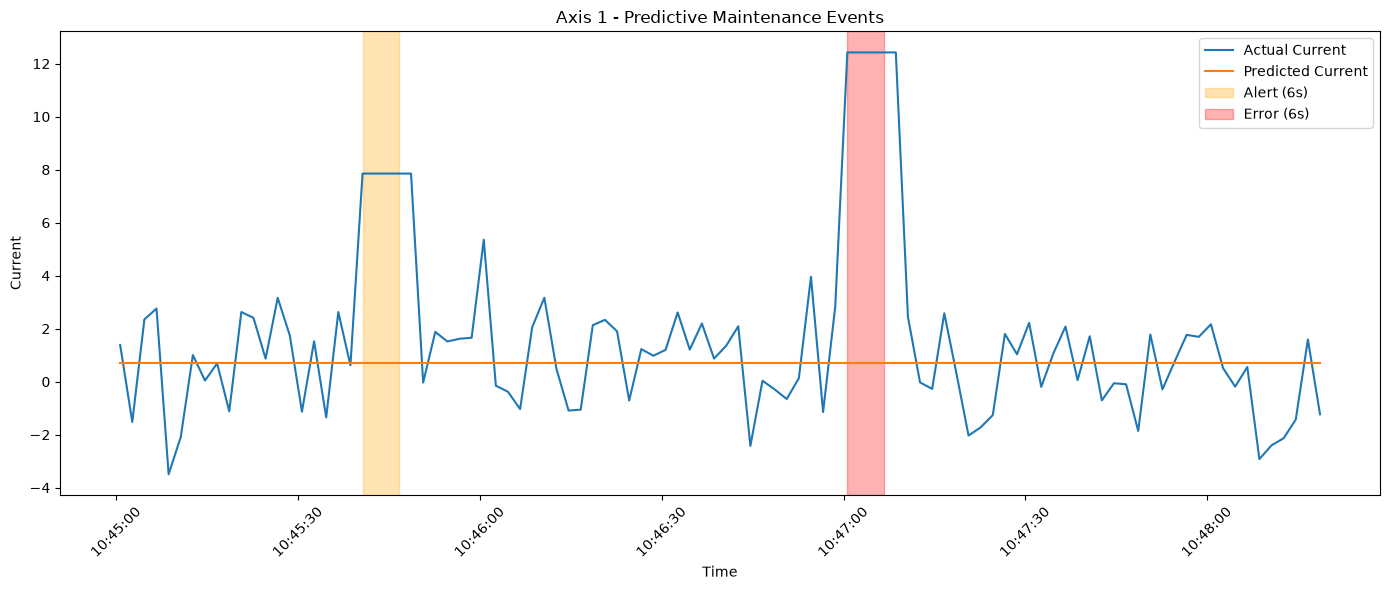

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    synthetic_df["time"],
    synthetic_df["axis_1"],
    label="Actual Current"
)

plt.plot(
    synthetic_df["time"],
    synthetic_df["axis_1_predicted"],
    label="Predicted Current"
)

axis_1_events = events_df[events_df["axis"] == "axis_1"]

for _, event in axis_1_events.iterrows():
    event_color = "orange" if event["event"] == "Alert" else "red"

    plt.axvspan(
        event["start_time"],
        event["detected_time"],
        color=event_color,
        alpha=0.3,
        label=f'{event["event"]} ({event["duration_seconds"]:.0f}s)'
    )

plt.title("Axis 1 - Predictive Maintenance Events")
plt.xlabel("Time")
plt.ylabel("Current")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Talking Point

The visualization compares the actual current with the expected current and highlights the periods where the deviation remained abnormal for at least T seconds.

## 17. Log Detected Events

Detected Alert and Error events are saved to a CSV file for later review.

In [23]:
from pathlib import Path

project_root = Path.cwd()

if project_root.name == "src":
    project_root = project_root.parent

log_file = project_root / "logs" / "predictive_events.csv"

events_df.to_csv(log_file, index=False)

print("Events saved to:", log_file)

Events saved to: c:\Conestoga_Projects\Foundations_Of_Machine_Learning_Frameworks\Predictive-Maintenance-Linear-Regression\logs\predictive_events.csv
